In [194]:
import tempfile
from telnetlib import X3PAD

tempdir = tempfile.gettempdir()

#**Random Fuzzy Number Generator**





In [195]:
#!pip install portion
#import portion as P
from random import random as rm
import math

## Alpha-cut based (for unimodal Fuzzy Numbers)
From "Fuzzy Uncertainty in Random Variable Generation: An a-Cut Approach", by Christian Alfredo Varón-Gaviria, José Luis Barbosa-Fontecha, and Juan Carlos Figueroa-García

In [196]:
def build_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else (c - x)/(c - b) if b <= x < c else 0

def build_sampleable_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = (c - b) / 2
  Lambda = (c - a) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda

  return lambda u1, u2: u1 * (b - a) + a if u2 <= lambda1 else c - u1 * (c - b)


In [197]:
%matplotlib inline
import matplotlib.pyplot as plt
#plt.style.use('seaborn-whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

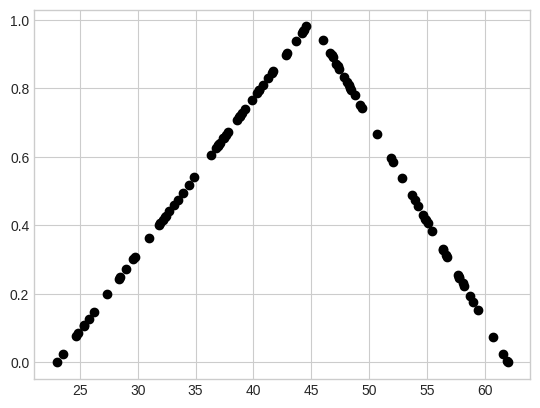

In [198]:
n = 100

sampler = build_sampleable_triangular_mf(23, 45, 62)
mf = build_triangular_mf(23, 45, 62)
x = [sampler(rm(), rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

## Cumulative membership function-based
From "Fuzzy Uncertainty in Random Variable Generation: A Cumulative Membership
Function Approach", by Diana Giseth Pulido-L´opez, Mabel García, and Juan Carlos Figueroa-García

In [199]:
def build_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else 1 if b <= x < c else (d - x)/(d - c) if c <= x < d else 0

def build_sampleable_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = c - b
  Lambda3 = (d - c) / 2
  Lambda = (c + d - a - b) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda
  lambda3 = Lambda3 / Lambda

  return lambda u: a + math.sqrt((b - a) * 2 * u * Lambda) if u <= lambda1 else u * Lambda + b - Lambda1 if u <= (lambda1 + lambda2) else d - math.sqrt((d - c)**2 - 2 * (d - c) * (u * Lambda - Lambda1 - Lambda2))


In [200]:
sampler = build_sampleable_trapezoidal_mf(23, 45, 62, 98)
mf = build_trapezoidal_mf(23, 45, 62, 98)

for j in range(100):
  r = sampler(rm())
  print("({}, {})".format(r, mf(r)))

(51.497527330674735, 1)
(26.454514897058917, 0.15702340441176899)
(50.180904922903935, 1)
(69.42570410660458, 0.793730441483206)
(75.9686498889622, 0.6119819475288276)
(85.58071181641203, 0.34498022732188793)
(53.2749790009718, 1)
(69.08239110257045, 0.8032669138174874)
(59.1220862477566, 1)
(61.749619091297106, 1)
(44.1274777792194, 0.9603398990554272)
(44.07390301946431, 0.9579046827029232)
(54.04845489814528, 1)
(30.664609290247718, 0.34839133137489625)
(49.4619590101256, 1)
(65.4011951632256, 0.9055223565770668)
(52.59856678033131, 1)
(41.277049432441274, 0.8307749742018761)
(55.499946864686265, 1)
(39.07229484849843, 0.7305588567499286)
(62.62932082566271, 0.9825188659538137)
(30.387834503831193, 0.33581065926505427)
(52.124931791626416, 1)
(59.96203121913962, 1)
(30.406385204186478, 0.33665387291756715)
(63.6021342843327, 0.9554962698796472)
(39.57274154009113, 0.7533064336405059)
(55.23812842636954, 1)
(33.08841405677732, 0.4585642753080599)
(51.43877775265442, 1)
(43.6978360038

In [201]:
%matplotlib inline
import matplotlib.pyplot as plt
#plt.style.use('seaborn-whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

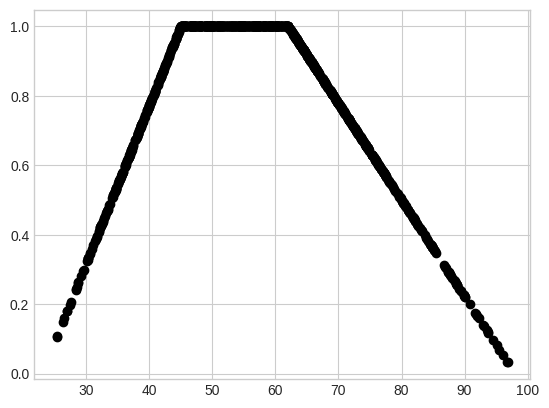

In [202]:
n = 1000
x = [sampler(rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

#**Simulación de una instancia de VRP utilizando Simpy**

Características:

*   1 vehiculo con límite de capacidad.
*   1 depósito (inicio y fin del recorrido).
*   N clientes.
*   Se posee una estimación de las demandas de los clientes y del tiempo de recorrido entre cada uno de ellos incluído el depósito.
*   La simulación finaliza al regresar al depósito.





## Instalación e importación de librerías necesarias

In [203]:
#!pip install simpy
#!pip install pandas

In [204]:
#import simpy
import random
import numpy as np
import pandas as pd


## Definicion e inicializacion de estructuras de datos



### Samplers for Random Fuzzy Number Generator

In [205]:
sampler_trapezoidal_prod_estimado = build_sampleable_trapezoidal_mf(30, 45, 55, 75)
sampler_trapezoidal_prod_estimado(rm())

49.39700287825431

### Tabla de distancias/tiempos estimados entre los clientes, incluyendo el deposito

In [206]:
# Importar matriz de adyacencia desde csv
#df = pd.read_csv('VRP-data - 2.csv',sep=";")
#df.index = df.columns
#df

In [207]:
ubicaciones = ['Frigorifico Tres Arroyos', 'La Blanq y D Gaspar', 'D Gaspar y La Blanquita', 'Rougier Carnes', 'La Pulperia',
       'Granja de Rosso', 'La Estancia', 'El Buen Trato', 'El Ternero Gasolero', 'La Imbatible', 'El tropezon',
       'Estancia La Argentina', 'La Providencia', 'Don Miguel', 'El Gauchito', 'Del Campo Carnes', 'El mejor corte',
       'Lo de gaston Araoz', 'Lo de gaston ruta', 'La Campeira', 'Don Adolfo']

tiempos = np.array([[ 0,  9,  6,  4,  4,  7,  9, 10, 12, 10,  8, 10, 10, 12, 12, 12,
         6,  7,  6,  9, 12],
       [ 8,  0,  5,  8,  8,  9,  9, 10, 11,  9,  9, 12, 12, 11, 13, 14,
         5, 10,  6, 16, 14],
       [ 6,  6,  0,  5,  5,  5,  5,  8,  7,  5,  7,  6,  7,  7,  8,  9,
         2,  6,  3, 10,  8],
       [ 4,  8,  5,  0,  1,  4,  5,  5,  7,  6,  8,  5,  7,  8,  3,  5,
         5,  6,  7, 12,  7],
       [ 5,  9,  6,  3,  0,  5,  7,  6,  8,  7,  6,  9,  9, 10, 10, 10,
         6,  6,  6,  7, 10],
       [ 7,  9,  6,  5,  5,  0,  4,  3,  5,  4,  3,  5,  5,  5,  6,  7,
         6,  1,  6,  7,  6],
       [ 8,  9,  5,  6,  5,  2,  0,  5,  4,  2,  4,  3,  4,  4,  5,  7,
         5,  3,  6,  8,  4],
       [ 9, 12,  9,  7,  6,  5,  6,  0,  5,  7,  3,  7,  5,  5,  8,  8,
        10,  5, 10,  4,  6],
       [10, 11,  7,  8,  7,  5,  4,  3,  0,  4,  4,  3,  2,  1,  4,  4,
         8,  5,  9,  6,  3],
       [ 9,  9,  6,  7,  6,  5,  3,  7,  6,  0,  6,  3,  5,  5,  3,  5,
         5,  5,  7, 10,  4],
       [ 7, 10,  6,  7,  4,  2,  4,  3,  5,  5,  0,  5,  5,  5,  7,  8,
         7,  2,  7,  6,  6],
       [ 9, 12,  6,  3,  6,  4,  2,  8,  4,  1,  5,  0,  4,  6,  3,  4,
         6,  4,  7, 10,  3],
       [ 9, 12,  7,  6,  6,  4,  4,  4,  3,  4,  3,  4,  0,  2,  5,  5,
         8,  4,  8,  7,  4],
       [10, 13,  9,  8,  7,  5,  6,  2,  4,  6,  4,  5,  3,  0,  6,  6,
        10,  5, 10,  6,  5],
       [12, 13,  8,  5,  9,  6,  5,  7,  5,  3,  6,  3,  5,  5,  0,  2,
         9,  7,  9,  8,  3],
       [12, 14,  8,  5,  9,  6,  4,  5,  4,  3,  6,  3,  4,  4,  4,  0,
         8,  7,  9,  8,  2],
       [ 6,  5,  2,  5,  6,  7,  5,  9,  8,  7,  8,  7,  8,  8,  9, 10,
         0,  7,  2, 12,  9],
       [ 6,  8,  5,  5,  4,  1,  3,  4,  5,  4,  3,  4,  5,  5,  6,  7,
         6,  0,  5,  6,  6],
       [ 7,  3,  4,  8,  8,  8,  9, 12, 12, 10, 10,  9,  9, 10, 10, 12,
         4,  8,  0, 12, 10],
       [ 9, 14, 10, 10,  6,  6,  8,  4,  5,  8,  6,  8,  6,  6,  9,  8,
        12,  7, 12,  0,  7],
       [12, 14,  8,  5,  9,  6,  4,  6,  3,  3,  7,  3,  5,  4,  4,  3,
         8,  7, 10,  7,  0]])
df_tiempos = pd.DataFrame(tiempos, columns=ubicaciones, index=ubicaciones)
df_tiempos

,Frigorifico Tres Arroyos,La Blanq y D Gaspar,D Gaspar y La Blanquita,Rougier Carnes,La Pulperia,Granja de Rosso,La Estancia,El Buen Trato,El Ternero Gasolero,La Imbatible,...,Estancia La Argentina,La Providencia,Don Miguel,El Gauchito,Del Campo Carnes,El mejor corte,Lo de gaston Araoz,Lo de gaston ruta,La Campeira,Don Adolfo
Frigorifico Tres Arroyos,0,9,6,4,4,7,9,10,12,10,...,10,10,12,12,12,6,7,6,9,12
La Blanq y D Gaspar,8,0,5,8,8,9,9,10,11,9,...,12,12,11,13,14,5,10,6,16,14
D Gaspar y La Blanquita,6,6,0,5,5,5,5,8,7,5,...,6,7,7,8,9,2,6,3,10,8
Rougier Carnes,4,8,5,0,1,4,5,5,7,6,...,5,7,8,3,5,5,6,7,12,7
La Pulperia,5,9,6,3,0,5,7,6,8,7,...,9,9,10,10,10,6,6,6,7,10
Granja de Rosso,7,9,6,5,5,0,4,3,5,4,...,5,5,5,6,7,6,1,6,7,6
La Estancia,8,9,5,6,5,2,0,5,4,2,...,3,4,4,5,7,5,3,6,8,4
El Buen Trato,9,12,9,7,6,5,6,0,5,7,...,7,5,5,8,8,10,5,10,4,6
El Ternero Gasolero,10,11,7,8,7,5,4,3,0,4,...,3,2,1,4,4,8,5,9,6,3
La Imbatible,9,9,6,7,6,5,3,7,6,0,...,3,5,5,3,5,5,5,7,10,4


### Tabla de Planificacion inicial de orden de visita, con estimacion de cantidad de productos requeridos

In [208]:
#Uncertainty:
############[1: low, 2: medium, 3: high]
def estimar(clientes, uncertainty=1):
    estimaciones = np.empty((0, 4), dtype=int)
    for i in clientes[1:len(clientes)]:
        delta = 0  #int(random.uniform(0,20))
        if uncertainty == 3:  #HU
            a = int(random.uniform(30, 33)) + delta
            b = int(random.uniform(43, 55)) + delta
            c = int(random.uniform(56, 62)) + delta
            d = int(random.uniform(77, 83)) + delta
        elif uncertainty == 2:  #MU
            a = int(random.uniform(35, 40)) + delta
            b = int(random.uniform(45, 55)) + delta
            c = int(random.uniform(56, 60)) + delta
            d = int(random.uniform(65, 70)) + delta
        else:  #LU
            a = int(random.uniform(45, 48)) + delta
            b = int(random.uniform(49, 53)) + delta
            c = int(random.uniform(54, 58)) + delta
            d = int(random.uniform(59, 61)) + delta
        estimaciones = np.append(estimaciones, np.array([[a, b, c, d]]), axis=0)
    return estimaciones


In [209]:
#Uncertainty:
############[1: low, 2: medium, 3: high]
def planificacion(clientes, uncertainty=1):
    data_plan = np.empty((0, 10))
    estimaciones = estimar(clientes, uncertainty)
    n = 1
    for i in clientes[1:len(clientes)]:
        sampler_trapezoidal = build_sampleable_trapezoidal_mf(estimaciones[n - 1][0], estimaciones[n - 1][1],
                                                              estimaciones[n - 1][2], estimaciones[n - 1][3])
        estimado = int(sampler_trapezoidal(rm()))
        pedido = int(sampler_trapezoidal(rm()))  #int(random.uniform(0.8,1.2)*estimado)
        data_plan = np.append(data_plan, np.array(
            [[i, n, estimaciones[n - 1][0], estimaciones[n - 1][1], estimaciones[n - 1][2], estimaciones[n - 1][3],
              estimado, 0, pedido, 0]]), axis=0)
        n = n + 1
    plan = pd.DataFrame(data_plan,
                        columns=['cliente', 'idCliente', 'estimacionA', 'estimacionB', 'estimacionC', 'estimacionD',
                                 'productosEstimados', 'productosPedidosConocido', 'productosPedidos',
                                 'productosRecibidos'])
    return plan

In [210]:
planificacion(ubicaciones)

,cliente,idCliente,estimacionA,estimacionB,estimacionC,estimacionD,productosEstimados,productosPedidosConocido,productosPedidos,productosRecibidos
0,La Blanq y D Gaspar,1,47,49,54,59,49,0,50,0
1,D Gaspar y La Blanquita,2,45,50,56,59,47,0,52,0
2,Rougier Carnes,3,47,52,57,59,56,0,55,0
3,La Pulperia,4,46,51,54,59,52,0,52,0
4,Granja de Rosso,5,46,51,54,60,56,0,52,0
5,La Estancia,6,45,51,56,60,56,0,55,0
6,El Buen Trato,7,47,51,57,59,55,0,52,0
7,El Ternero Gasolero,8,45,51,56,60,52,0,53,0
8,La Imbatible,9,47,50,56,59,50,0,53,0
9,El tropezon,10,46,50,57,59,48,0,53,0


### **Graph Embeddings**

Descripción





## Instalación e importación de librerías necesarias

In [211]:
#!pip install networkx==2.7

In [212]:
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

In [213]:
ubicaciones = ['Frigorifico Tres Arroyos', 'La Blanq y D Gaspar', 'D Gaspar y La Blanquita', 'Rougier Carnes', 'La Pulperia', 'Granja de Rosso', 'La Estancia', 'El Buen Trato',
               'El Ternero Gasolero', 'La Imbatible', 'El tropezon', 'Estancia La Argentina', 'La Providencia', 'Don Miguel', 'El Gauchito', 'Del Campo Carnes', 'El mejor corte',
              'Lo de gaston Araoz', 'Lo de gaston ruta', 'La Campeira', 'Don Adolfo']

tiempos = np.array([[ 0,  9,  6,  4,  4,  7,  9, 10, 12, 10,  8, 10, 10, 12, 12, 12, 6,  7,  6,  9, 12],
       [ 8,  0,  5,  8,  8,  9,  9, 10, 11,  9,  9, 12, 12, 11, 13, 14, 5, 10,  6, 16, 14],
       [ 6,  6,  0,  5,  5,  5,  5,  8,  7,  5,  7,  6,  7,  7,  8,  9, 2,  6,  3, 10,  8],
       [ 4,  8,  5,  0,  1,  4,  5,  5,  7,  6,  8,  5,  7,  8,  3,  5, 5,  6,  7, 12,  7],
       [ 5,  9,  6,  3,  0,  5,  7,  6,  8,  7,  6,  9,  9, 10, 10, 10, 6,  6,  6,  7, 10],
       [ 7,  9,  6,  5,  5,  0,  4,  3,  5,  4,  3,  5,  5,  5,  6,  7, 6,  1,  6,  7,  6],
       [ 8,  9,  5,  6,  5,  2,  0,  5,  4,  2,  4,  3,  4,  4,  5,  7, 5,  3,  6,  8,  4],
       [ 9, 12,  9,  7,  6,  5,  6,  0,  5,  7,  3,  7,  5,  5,  8,  8, 10,  5, 10,  4,  6],
       [10, 11,  7,  8,  7,  5,  4,  3,  0,  4,  4,  3,  2,  1,  4,  4, 8,  5,  9,  6,  3],
       [ 9,  9,  6,  7,  6,  5,  3,  7,  6,  0,  6,  3,  5,  5,  3,  5, 5,  5,  7, 10,  4],
       [ 7, 10,  6,  7,  4,  2,  4,  3,  5,  5,  0,  5,  5,  5,  7,  8, 7,  2,  7,  6,  6],
       [ 9, 12,  6,  3,  6,  4,  2,  8,  4,  1,  5,  0,  4,  6,  3,  4, 6,  4,  7, 10,  3],
       [ 9, 12,  7,  6,  6,  4,  4,  4,  3,  4,  3,  4,  0,  2,  5,  5, 8,  4,  8,  7,  4],
       [10, 13,  9,  8,  7,  5,  6,  2,  4,  6,  4,  5,  3,  0,  6,  6, 10,  5, 10,  6,  5],
       [12, 13,  8,  5,  9,  6,  5,  7,  5,  3,  6,  3,  5,  5,  0,  2, 9,  7,  9,  8,  3],
       [12, 14,  8,  5,  9,  6,  4,  5,  4,  3,  6,  3,  4,  4,  4,  0, 8,  7,  9,  8,  2],
       [ 6,  5,  2,  5,  6,  7,  5,  9,  8,  7,  8,  7,  8,  8,  9, 10, 0,  7,  2, 12,  9],
       [ 6,  8,  5,  5,  4,  1,  3,  4,  5,  4,  3,  4,  5,  5,  6,  7, 6,  0,  5,  6,  6],
       [ 7,  3,  4,  8,  8,  8,  9, 12, 12, 10, 10,  9,  9, 10, 10, 12, 4,  8,  0, 12, 10],
       [ 9, 14, 10, 10,  6,  6,  8,  4,  5,  8,  6,  8,  6,  6,  9,  8, 12,  7, 12,  0,  7],
       [12, 14,  8,  5,  9,  6,  4,  6,  3,  3,  7,  3,  5,  4,  4,  3, 8,  7, 10,  7,  0]])
df_tiempos = pd.DataFrame(tiempos, columns=ubicaciones, index=ubicaciones)
df_tiempos

,Frigorifico Tres Arroyos,La Blanq y D Gaspar,D Gaspar y La Blanquita,Rougier Carnes,La Pulperia,Granja de Rosso,La Estancia,El Buen Trato,El Ternero Gasolero,La Imbatible,...,Estancia La Argentina,La Providencia,Don Miguel,El Gauchito,Del Campo Carnes,El mejor corte,Lo de gaston Araoz,Lo de gaston ruta,La Campeira,Don Adolfo
Frigorifico Tres Arroyos,0,9,6,4,4,7,9,10,12,10,...,10,10,12,12,12,6,7,6,9,12
La Blanq y D Gaspar,8,0,5,8,8,9,9,10,11,9,...,12,12,11,13,14,5,10,6,16,14
D Gaspar y La Blanquita,6,6,0,5,5,5,5,8,7,5,...,6,7,7,8,9,2,6,3,10,8
Rougier Carnes,4,8,5,0,1,4,5,5,7,6,...,5,7,8,3,5,5,6,7,12,7
La Pulperia,5,9,6,3,0,5,7,6,8,7,...,9,9,10,10,10,6,6,6,7,10
Granja de Rosso,7,9,6,5,5,0,4,3,5,4,...,5,5,5,6,7,6,1,6,7,6
La Estancia,8,9,5,6,5,2,0,5,4,2,...,3,4,4,5,7,5,3,6,8,4
El Buen Trato,9,12,9,7,6,5,6,0,5,7,...,7,5,5,8,8,10,5,10,4,6
El Ternero Gasolero,10,11,7,8,7,5,4,3,0,4,...,3,2,1,4,4,8,5,9,6,3
La Imbatible,9,9,6,7,6,5,3,7,6,0,...,3,5,5,3,5,5,5,7,10,4


In [214]:
planificacion1 = planificacion(ubicaciones)
planificacion1

,cliente,idCliente,estimacionA,estimacionB,estimacionC,estimacionD,productosEstimados,productosPedidosConocido,productosPedidos,productosRecibidos
0,La Blanq y D Gaspar,1,46,50,56,59,55,0,57,0
1,D Gaspar y La Blanquita,2,47,51,55,59,55,0,51,0
2,Rougier Carnes,3,47,51,56,59,51,0,55,0
3,La Pulperia,4,47,50,56,60,51,0,52,0
4,Granja de Rosso,5,46,52,56,60,51,0,53,0
5,La Estancia,6,45,50,57,60,49,0,53,0
6,El Buen Trato,7,47,51,56,60,57,0,55,0
7,El Ternero Gasolero,8,45,51,56,60,49,0,54,0
8,La Imbatible,9,45,51,54,60,53,0,50,0
9,El tropezon,10,45,49,55,59,53,0,52,0


In [215]:
A = tiempos
B = df_tiempos
#G = nx.from_numpy_matrix(A)
GP = nx.from_pandas_adjacency(B)
G = nx.from_numpy_array(A)

In [216]:
# nx.draw(GP, with_labels=True, font_weight='bold')

In [217]:
Grafos = []

In [218]:
A = tiempos
planificacion1 = planificacion(ubicaciones)

G1 = nx.from_numpy_array(A)

G1.nodes[0]['demanda'] = 0 #DEPOSITO
G1.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

for i in range(1,len(G1.nodes)):
    A = int(planificacion1.at[i-1,"estimacionA"])
    B = int(planificacion1.at[i-1,"estimacionB"])
    C = int(planificacion1.at[i-1,"estimacionC"])
    D = int(planificacion1.at[i-1,"estimacionD"])
    estimacion = build_sampleable_trapezoidal_mf(A, B, C, D)(rm())
    pedido = int(planificacion1.at[i-1,"productosPedidosConocido"])

    #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
    if pedido>0 :
        G1.nodes[i]['demanda'] = pedido
    else:
        G1.nodes[i]['demanda'] = estimacion
    G1.nodes[i]['productosRecibidos'] = int(planificacion1.at[i-1,"productosRecibidos"])

# División en 2 VRP de 10 clientes cada uno
G2 = G1.copy()
G2.remove_nodes_from([20,19,18,17,16,15,14,13,12,11])
G1.remove_nodes_from([10,9,8,7,6,5,4,3,2,1])

Grafos.append(G1)
Grafos.append(G2)

# Reducción a 8 clientes
G1_8 = G1.copy()
G1_8.remove_nodes_from([20,19])
Grafos.append(G1_8)

# Reducción a 6 clientes
G1_6 = G1_8.copy()
G1_6.remove_nodes_from([18,17])
Grafos.append(G1_6)

# Reducción a 4 clientes
G1_4 = G1_6.copy()
G1_4.remove_nodes_from([16,15])
Grafos.append(G1_4)

# Reducción a 2 clientes
G1_2 = G1_4.copy()
G1_2.remove_nodes_from([14,13])
Grafos.append(G1_2)

# Reducción a 8 clientes
G2_8 = G2.copy()
G2_8.remove_nodes_from([10,9])
Grafos.append(G2_8)

# Reducción a 6 clientes
G2_6 = G2_8.copy()
G2_6.remove_nodes_from([8,7])
Grafos.append(G2_6)

# Reducción a 4 clientes
G2_4 = G2_6.copy()
G2_4.remove_nodes_from([6,5])
Grafos.append(G2_4)

# Reducción a 2 clientes
G2_2 = G2_4.copy()
G2_2.remove_nodes_from([4,3])
Grafos.append(G2_2)

In [219]:
a= 0.7
b= 1.7
times_change = np.random.uniform(a,b,len(tiempos))
tiempos_2 = times_change * tiempos
A = tiempos_2

planificacion1 = planificacion(ubicaciones)

G1 = nx.from_numpy_array(A)

G1.nodes[0]['demanda'] = 0 #DEPOSITO
G1.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

for i in range(1,len(G1.nodes)):
    A = int(planificacion1.at[i-1,"estimacionA"])
    B = int(planificacion1.at[i-1,"estimacionB"])
    C = int(planificacion1.at[i-1,"estimacionC"])
    D = int(planificacion1.at[i-1,"estimacionD"])
    estimacion = build_sampleable_trapezoidal_mf(A, B, C, D)(rm())
    pedido = int(planificacion1.at[i-1,"productosPedidosConocido"])

    #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
    if pedido>0 :
        G1.nodes[i]['demanda'] = pedido
    else:
        G1.nodes[i]['demanda'] = estimacion
    G1.nodes[i]['productosRecibidos'] = int(planificacion1.at[i-1,"productosRecibidos"])

# División en 2 VRP de 10 clientes cada uno
G2 = G1.copy()
G2.remove_nodes_from([20,19,18,17,16,15,14,13,12,11])
G1.remove_nodes_from([10,9,8,7,6,5,4,3,2,1])

Grafos.append(G1)
Grafos.append(G2)

# Reducción a 8 clientes
G1_8 = G1.copy()
G1_8.remove_nodes_from([20,19])
Grafos.append(G1_8)

# Reducción a 6 clientes
G1_6 = G1_8.copy()
G1_6.remove_nodes_from([18,17])
Grafos.append(G1_6)

# Reducción a 4 clientes
G1_4 = G1_6.copy()
G1_4.remove_nodes_from([16,15])
Grafos.append(G1_4)

# Reducción a 2 clientes
G1_2 = G1_4.copy()
G1_2.remove_nodes_from([14,13])
Grafos.append(G1_2)

# Reducción a 8 clientes
G2_8 = G2.copy()
G2_8.remove_nodes_from([10,9])
Grafos.append(G2_8)

# Reducción a 6 clientes
G2_6 = G2_8.copy()
G2_6.remove_nodes_from([8,7])
Grafos.append(G2_6)

# Reducción a 4 clientes
G2_4 = G2_6.copy()
G2_4.remove_nodes_from([6,5])
Grafos.append(G2_4)

# Reducción a 2 clientes
G2_2 = G2_4.copy()
G2_2.remove_nodes_from([4,3])
Grafos.append(G2_2)



In [220]:
a= 0.9
b= 1.5
times_change = np.random.uniform(a,b,len(tiempos))
tiempos_2 = times_change * tiempos

A = tiempos_2

planificacion1 = planificacion(ubicaciones)

G1 = nx.from_numpy_array(A)

G1.nodes[0]['demanda'] = 0 #DEPOSITO
G1.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

for i in range(1,len(G1.nodes)):
    A = int(planificacion1.at[i-1,"estimacionA"])
    B = int(planificacion1.at[i-1,"estimacionB"])
    C = int(planificacion1.at[i-1,"estimacionC"])
    D = int(planificacion1.at[i-1,"estimacionD"])
    estimacion = build_sampleable_trapezoidal_mf(A, B, C, D)(rm())
    pedido = int(planificacion1.at[i-1,"productosPedidosConocido"])

    #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
    if pedido>0 :
        G1.nodes[i]['demanda'] = pedido
    else:
        G1.nodes[i]['demanda'] = estimacion
    G1.nodes[i]['productosRecibidos'] = int(planificacion1.at[i-1,"productosRecibidos"])

# División en 2 VRP de 10 clientes cada uno
G2 = G1.copy()
G2.remove_nodes_from([20,19,18,17,16,15,14,13,12,11])
G1.remove_nodes_from([10,9,8,7,6,5,4,3,2,1])

Grafos.append(G1)
Grafos.append(G2)

# Reducción a 8 clientes
G1_8 = G1.copy()
G1_8.remove_nodes_from([20,19])
Grafos.append(G1_8)

# Reducción a 6 clientes
G1_6 = G1_8.copy()
G1_6.remove_nodes_from([18,17])
Grafos.append(G1_6)

# Reducción a 4 clientes
G1_4 = G1_6.copy()
G1_4.remove_nodes_from([16,15])
Grafos.append(G1_4)

# Reducción a 2 clientes
G1_2 = G1_4.copy()
G1_2.remove_nodes_from([14,13])
Grafos.append(G1_2)

# Reducción a 8 clientes
G2_8 = G2.copy()
G2_8.remove_nodes_from([10,9])
Grafos.append(G2_8)

# Reducción a 6 clientes
G2_6 = G2_8.copy()
G2_6.remove_nodes_from([8,7])
Grafos.append(G2_6)

# Reducción a 4 clientes
G2_4 = G2_6.copy()
G2_4.remove_nodes_from([6,5])
Grafos.append(G2_4)

# Reducción a 2 clientes
G2_2 = G2_4.copy()
G2_2.remove_nodes_from([4,3])
Grafos.append(G2_2)


In [221]:
a= 0.8
b= 1.4
times_change = np.random.uniform(a,b,len(tiempos))
tiempos_2 = times_change * tiempos

A = tiempos_2

planificacion1 = planificacion(ubicaciones)

G1 = nx.from_numpy_array(A)

G1.nodes[0]['demanda'] = 0 #DEPOSITO
G1.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

for i in range(1,len(G1.nodes)):
    A = int(planificacion1.at[i-1,"estimacionA"])
    B = int(planificacion1.at[i-1,"estimacionB"])
    C = int(planificacion1.at[i-1,"estimacionC"])
    D = int(planificacion1.at[i-1,"estimacionD"])
    estimacion = build_sampleable_trapezoidal_mf(A, B, C, D)(rm())
    pedido = int(planificacion1.at[i-1,"productosPedidosConocido"])

    #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
    if pedido>0 :
        G1.nodes[i]['demanda'] = pedido
    else:
        G1.nodes[i]['demanda'] = estimacion
    G1.nodes[i]['productosRecibidos'] = int(planificacion1.at[i-1,"productosRecibidos"])

# División en 2 VRP de 10 clientes cada uno
G2 = G1.copy()
G2.remove_nodes_from([20,19,18,17,16,15,14,13,12,11])
G1.remove_nodes_from([10,9,8,7,6,5,4,3,2,1])

Grafos.append(G1)
Grafos.append(G2)

# Reducción a 8 clientes
G1_8 = G1.copy()
G1_8.remove_nodes_from([20,19])
Grafos.append(G1_8)

# Reducción a 6 clientes
G1_6 = G1_8.copy()
G1_6.remove_nodes_from([18,17])
Grafos.append(G1_6)

# Reducción a 4 clientes
G1_4 = G1_6.copy()
G1_4.remove_nodes_from([16,15])
Grafos.append(G1_4)

# Reducción a 2 clientes
G1_2 = G1_4.copy()
G1_2.remove_nodes_from([14,13])
Grafos.append(G1_2)

# Reducción a 8 clientes
G2_8 = G2.copy()
G2_8.remove_nodes_from([10,9])
Grafos.append(G2_8)

# Reducción a 6 clientes
G2_6 = G2_8.copy()
G2_6.remove_nodes_from([8,7])
Grafos.append(G2_6)

# Reducción a 4 clientes
G2_4 = G2_6.copy()
G2_4.remove_nodes_from([6,5])
Grafos.append(G2_4)

# Reducción a 2 clientes
G2_2 = G2_4.copy()
G2_2.remove_nodes_from([4,3])
Grafos.append(G2_2)


In [222]:
a= 1.2
b= 2
times_change = np.random.uniform(a,b,len(tiempos))
tiempos_2 = times_change * tiempos

A = tiempos_2

planificacion1 = planificacion(ubicaciones)

G1 = nx.from_numpy_array(A)

G1.nodes[0]['demanda'] = 0 #DEPOSITO
G1.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

for i in range(1,len(G1.nodes)):
    A = int(planificacion1.at[i-1,"estimacionA"])
    B = int(planificacion1.at[i-1,"estimacionB"])
    C = int(planificacion1.at[i-1,"estimacionC"])
    D = int(planificacion1.at[i-1,"estimacionD"])
    estimacion = build_sampleable_trapezoidal_mf(A, B, C, D)(rm())
    pedido = int(planificacion1.at[i-1,"productosPedidosConocido"])

    #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
    if pedido>0 :
        G1.nodes[i]['demanda'] = pedido
    else:
        G1.nodes[i]['demanda'] = estimacion
    G1.nodes[i]['productosRecibidos'] = int(planificacion1.at[i-1,"productosRecibidos"])

# División en 2 VRP de 10 clientes cada uno
G2 = G1.copy()
G2.remove_nodes_from([20,19,18,17,16,15,14,13,12,11])
G1.remove_nodes_from([10,9,8,7,6,5,4,3,2,1])

Grafos.append(G1)
Grafos.append(G2)

# Reducción a 8 clientes
G1_8 = G1.copy()
G1_8.remove_nodes_from([20,19])
Grafos.append(G1_8)

# Reducción a 6 clientes
G1_6 = G1_8.copy()
G1_6.remove_nodes_from([18,17])
Grafos.append(G1_6)

# Reducción a 4 clientes
G1_4 = G1_6.copy()
G1_4.remove_nodes_from([16,15])
Grafos.append(G1_4)

# Reducción a 2 clientes
G1_2 = G1_4.copy()
G1_2.remove_nodes_from([14,13])
Grafos.append(G1_2)

# Reducción a 8 clientes
G2_8 = G2.copy()
G2_8.remove_nodes_from([10,9])
Grafos.append(G2_8)

# Reducción a 6 clientes
G2_6 = G2_8.copy()
G2_6.remove_nodes_from([8,7])
Grafos.append(G2_6)

# Reducción a 4 clientes
G2_4 = G2_6.copy()
G2_4.remove_nodes_from([6,5])
Grafos.append(G2_4)

# Reducción a 2 clientes
G2_2 = G2_4.copy()
G2_2.remove_nodes_from([4,3])
Grafos.append(G2_2)



In [223]:
for i in range(len(Grafos)-1):
    mapping = dict(zip(Grafos[i], range(0, 27)))
    Grafos[i] = nx.relabel_nodes(Grafos[i], mapping)
    print(sorted(Grafos[i]))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4

In [224]:
Grafos

In [225]:
len(Grafos)

50

## Distancias Grafos

In [226]:
# arguments for nodes
def node_subst_cost(node1, node2):
    # check if the nodes are equal, if yes then apply no cost, else apply 1
    if node1 == node2:
        return 0
    #demanda_sin_cubrir1 = (node1['demanda'] - node1['productosRecibidos'])
    #demanda_sin_cubrir2 = (node2['demanda'] - node2['productosRecibidos'])
    return abs((node1['demanda'] - node1['productosRecibidos']) - (node2['demanda'] - node2['productosRecibidos']))

def node_del_cost(node): # here you apply the cost for node deletion
    return abs(node['demanda'] - node['productosRecibidos'])

def node_ins_cost(node): # here you apply the cost for node insertion
    return abs(node['demanda'] - node['productosRecibidos'])

# arguments for edges
def edge_subst_cost(edge1, edge2):
    # check if the edges are equal, if yes then apply no cost, else apply 3
    if edge1==edge2:
        return 0
    return abs(edge1['weight'] - edge2['weight'])

def edge_del_cost(edge):
    return edge['weight'] # here you apply the cost for edge deletion

def edge_ins_cost(edge):
    return edge['weight']  # here you apply the cost for edge insertion

cost_function = lambda G1,G2: nx.graph_edit_distance(
    G1,
    G2,
    node_subst_cost=node_subst_cost,
    node_del_cost=node_del_cost,
    node_ins_cost=node_ins_cost,
    edge_subst_cost=edge_subst_cost,
    edge_del_cost=edge_del_cost,
    edge_ins_cost=edge_ins_cost
)

In [227]:
G1_2.nodes[0]['demanda']

0

In [228]:
G1_2.edges

EdgeView([(0, 11), (0, 12), (11, 12)])

In [229]:
print(cost_function(G1_8,G1_2))

677.1538895824988


In [230]:
range(len(Grafos))

range(0, 50)

In [231]:
def graphs_distance(G):
  y = []
  #vamos agregando las distancias
  for i in range(len(G)-1):
    for g in range(i+1,len(G)-1):
        y.append(cost_function(G[i],G[g]))
  return y

In [232]:
def graphs_distance2(G):
  y = []
  #vamos agregando las distancias
  for i in range(len(G)):
    for g in range(i+1,len(G)):
        y.append(cost_function(G[i],G[g]))
  return y

In [233]:
Gdistancias = graphs_distance2(Grafos)

In [234]:
Gdist = np.asarray(Gdistancias)
normalized_dist = Gdist/np.linalg.norm(Gdist)

In [235]:
np.savetxt('datos.txt', Gdist)
Gdist = np.loadtxt('datos.txt')
Gdist

array([109.82010317, 245.13546   , 458.75921177, ..., 206.57516375,
       371.19422171, 164.61905796])

In [236]:
np.save("array_distancias_grafos", Gdist)
b = np.load("array_distancias_grafos.npy")

# **karate club embeddings**

In [237]:
#!pip install --upgrade pip setuptools wheel

In [238]:
#!pip install --upgrade pip
#!pip install karateclub --upgrade


In [239]:
import karateclub

In [240]:
import networkx as nx
from karateclub import DeepWalk
from karateclub.graph_embedding import GL2Vec
from karateclub.graph_embedding import Graph2Vec
from karateclub.graph_embedding import WaveletCharacteristic

In [241]:
for i in range(len(Grafos)-1):
    mapping = dict(zip(Grafos[i], range(0, 27)))
    Grafos[i] = nx.relabel_nodes(Grafos[i], mapping)
    print(sorted(Grafos[i]))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[0, 1, 2]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4

In [242]:
model_Graph2Vec = Graph2Vec(wl_iterations = 4, attributed = False, dimensions= 720, workers = 8, down_sampling= 0.0001, epochs= 50, learning_rate= 0.0125, min_count= 5, erase_base_features = False)
model_Graph2Vec.fit(Grafos)
embedding = model_Graph2Vec.get_embedding()

model_GL2Vec = GL2Vec(wl_iterations=4, dimensions=720, workers=8, down_sampling=0.0001, epochs=80, learning_rate=0.0125, min_count=5, seed=42, erase_base_features=False)
model_GL2Vec.fit(Grafos)
embedding1 = model_GL2Vec.get_embedding()

model_WaveletCharacteristic=  WaveletCharacteristic(order= 3, eval_points= 30, theta_max = 2.5, tau = 1.0, pooling = 'mean')
#pooling = 'mean', 'max', 'min'
model_WaveletCharacteristic.fit(Grafos)
embedding2 = model_WaveletCharacteristic.get_embedding()

model_GL2Vec_128 = GL2Vec(wl_iterations=4, dimensions=128, workers=8, down_sampling=0.0001, epochs=80, learning_rate=0.0125, min_count=5, seed=42, erase_base_features=False)
model_GL2Vec_128.fit(Grafos)
embedding3 = model_GL2Vec_128.get_embedding()

In [243]:
X = model_Graph2Vec.infer(Grafos)
X
X1 = model_GL2Vec.infer(Grafos)
X1
X2 = model_WaveletCharacteristic.infer(Grafos)
X2
X3 = model_GL2Vec_128.infer(Grafos)
X3

array([[-0.02180905,  0.40587622, -0.12265615, ...,  0.00990134,
        -0.07015733,  0.39116707],
       [-0.03670118,  0.39827222, -0.12988052, ...,  0.00121051,
        -0.06452622,  0.3962684 ],
       [ 0.04115344, -0.33480805, -0.33536234, ...,  0.0479363 ,
         0.13834965,  0.05140695],
       ...,
       [ 0.46518776, -0.06629686,  0.08909594, ...,  0.21571155,
        -0.08603394, -0.15361083],
       [ 0.14477953,  0.02655489, -0.12392795, ...,  0.15460312,
         0.00573807, -0.03726592],
       [ 0.16187485,  0.00904218, -0.1377355 , ...,  0.09634572,
         0.00612038,  0.06236514]], dtype=float32)

In [244]:
len(X1[0])

720

In [245]:
import pickle
# save the model to disk
filename = 'trained_Graph2Vec_model.sav'
pickle.dump(model_Graph2Vec, open(filename, 'wb'))

filename = 'trained_GL2Vec_model.sav'
pickle.dump(model_GL2Vec, open(filename, 'wb'))

filename = 'trained_GL2Vec_model_128.sav'
pickle.dump(model_GL2Vec_128, open(filename, 'wb'))

filename = 'trained_WaveletCharacteristic_model.sav'
pickle.dump(model_WaveletCharacteristic, open(filename, 'wb'))

# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))

X4 = loaded_model.infer(Grafos)

# **Análisis de Correlación**

In [246]:
from scipy.spatial import distance

Y = distance.pdist(X, 'euclidean')
Y1 = distance.pdist(X1, 'euclidean')
Y2 = distance.pdist(X2, 'euclidean')
Y3 = distance.pdist(X3, 'euclidean')

In [247]:
len(Y3)

1225

In [248]:
len(Gdist)

1225

In [249]:
import matplotlib.pyplot as plt

array_distances = np.array([Gdist,Y,Y1,Y2,Y3])

array_distances = array_distances.transpose()

df = pd.DataFrame(array_distances, columns = ['GraphDist','Graph2Vec','GL2Vec','WaveletCh', 'GL2Vec128'])
df.head()

,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
0,109.820103,0.001180,0.056542,9.678451e-16,0.085604
1,245.135460,0.015420,4.074223,3.254263e+00,3.779154
2,458.759212,0.015720,2.973332,7.040113e+00,3.340172
3,634.503562,0.014773,2.435237,1.138439e+01,2.462130
4,785.662255,0.015904,2.373812,1.611925e+01,2.232001


In [269]:
# Guardar el DataFrame en un archivo CSV sin el índice
df.to_csv('archivo_distancias.csv', index=False)

# Mismo archivo con punto y coma como separador
df.to_csv('archivo_distancias_puntoycoma.csv', index=False, sep=';')

In [250]:
correlacionPearson = df.corr(method="pearson")
correlacionKendall = df.corr(method="kendall")
correlacionSpearman = df.corr(method="spearman")
correlacionPearson

,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
GraphDist,1.000000,0.563937,0.618734,0.868211,0.557471
Graph2Vec,0.563937,1.000000,0.611104,0.657177,0.720237
GL2Vec,0.618734,0.611104,1.000000,0.363812,0.951208
WaveletCh,0.868211,0.657177,0.363812,1.000000,0.348912
GL2Vec128,0.557471,0.720237,0.951208,0.348912,1.000000


In [251]:
correlacionKendall

,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
GraphDist,1.000000,0.115724,0.562940,0.636898,0.476575
Graph2Vec,0.115724,1.000000,0.173341,0.192150,0.201032
GL2Vec,0.562940,0.173341,1.000000,0.293227,0.889940
WaveletCh,0.636898,0.192150,0.293227,1.000000,0.205979
GL2Vec128,0.476575,0.201032,0.889940,0.205979,1.000000


In [252]:
correlacionSpearman

,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
GraphDist,1.000000,0.229021,0.746957,0.865844,0.648935
Graph2Vec,0.229021,1.000000,0.288876,0.326248,0.329287
GL2Vec,0.746957,0.288876,1.000000,0.440028,0.973288
WaveletCh,0.865844,0.326248,0.440028,1.000000,0.323163
GL2Vec128,0.648935,0.329287,0.973288,0.323163,1.000000


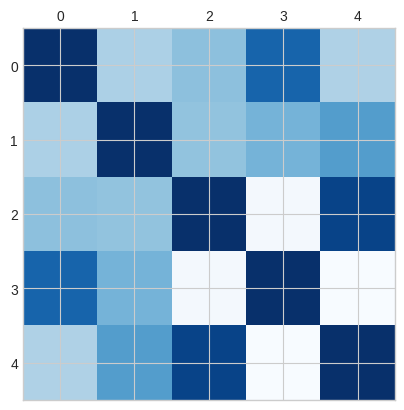

In [253]:
plt.matshow(df.corr(method="pearson"),cmap=plt.cm.Blues)

/tmp/ipykernel_690600/1022726241.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['']+columns)
/tmp/ipykernel_690600/1022726241.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(['']+columns)


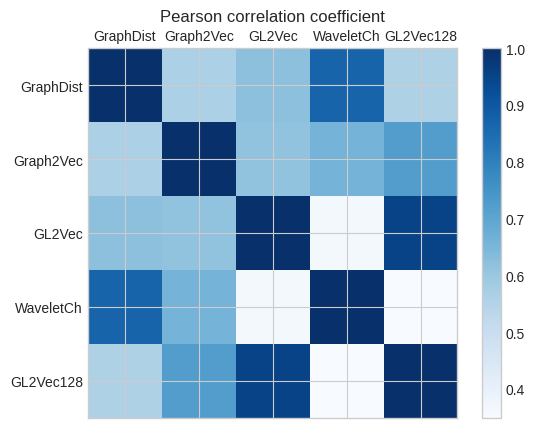

In [254]:
figure = plt.figure()
axes = figure.add_subplot(111)

# using the matshow() function
caxes = axes.matshow(df.corr(method="pearson"),cmap=plt.cm.Blues, interpolation ='nearest')
figure.colorbar(caxes)
figure

columns = ['GraphDist','Graph2Vec','GL2Vec','WaveletCh', 'GL2Vec128'] #,'DiffPool','MinCutPool']
axes.set_xticklabels(['']+columns)
axes.set_yticklabels(['']+columns)
axes.set_title("Pearson correlation coefficient")

plt.show()

/tmp/ipykernel_690600/1125298275.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['']+columns)
/tmp/ipykernel_690600/1125298275.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(['']+columns)


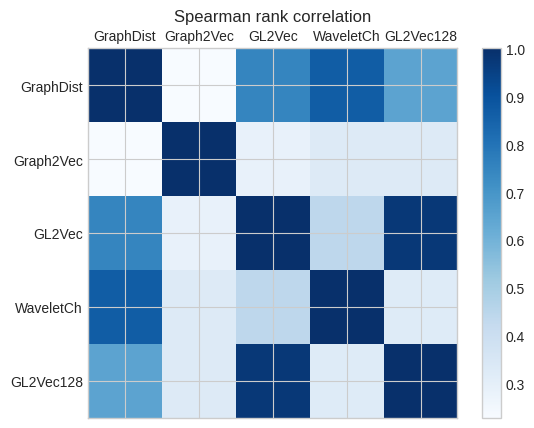

In [255]:
figure = plt.figure()
axes = figure.add_subplot(111)

# using the matshow() function
caxes = axes.matshow(df.corr(method="spearman"),cmap=plt.cm.Blues, interpolation ='nearest')
figure.colorbar(caxes)
figure

columns = ['GraphDist','Graph2Vec','GL2Vec','WaveletCh', 'GL2Vec128'] #,'DiffPool','MinCutPool']
axes.set_xticklabels(['']+columns)
axes.set_yticklabels(['']+columns)
axes.set_title("Spearman rank correlation")

plt.show()

In [256]:
data = df.copy()
data.columns

Index(['GraphDist', 'Graph2Vec', 'GL2Vec', 'WaveletCh', 'GL2Vec128'], dtype='object')

In [257]:
from sklearn.preprocessing import MinMaxScaler

data = df.copy()


scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns = ['GraphDist','Graph2Vec','GL2Vec','WaveletCh', 'GL2Vec128']) #,'DiffPool','MinCutPool'])

scaled_data



,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
0,0.101947,0.045316,0.012303,4.944014e-18,0.019475
1,0.234139,0.849231,0.953566,2.018867e-01,0.963732
2,0.442832,0.866157,0.695649,4.367518e-01,0.851507
3,0.614519,0.812692,0.569584,7.062607e-01,0.627035
4,0.762189,0.876561,0.555193,1.000000e+00,0.568202
...,...,...,...,...,...
1220,0.468329,0.882339,0.418301,5.308571e-01,0.520290
1221,0.629148,0.935790,0.437434,8.653261e-01,0.497072
1222,0.196468,0.871855,0.223539,3.019903e-01,0.434985
1223,0.357288,0.878290,0.243492,6.747246e-01,0.440603


In [258]:
scaled_data.corr(method="pearson")
#scaled_data.corr(method="spearman")

,GraphDist,Graph2Vec,GL2Vec,WaveletCh,GL2Vec128
GraphDist,1.000000,0.563937,0.618734,0.868211,0.557471
Graph2Vec,0.563937,1.000000,0.611104,0.657177,0.720237
GL2Vec,0.618734,0.611104,1.000000,0.363812,0.951208
WaveletCh,0.868211,0.657177,0.363812,1.000000,0.348912
GL2Vec128,0.557471,0.720237,0.951208,0.348912,1.000000


In [259]:
scaled_data['GraphDist']
scaled_data['GraphDist']
scaled_data['Graph2Vec']
scaled_data['GL2Vec']
scaled_data['WaveletCh']
scaled_data['GL2Vec128']
#scaled_data['DiffPool']
#scaled_data['MinCutPool']

0       0.019475
1       0.963732
2       0.851507
3       0.627035
4       0.568202
          ...   
1220    0.520290
1221    0.497072
1222    0.434985
1223    0.440603
1224    0.145744
Name: GL2Vec128, Length: 1225, dtype: float64

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt

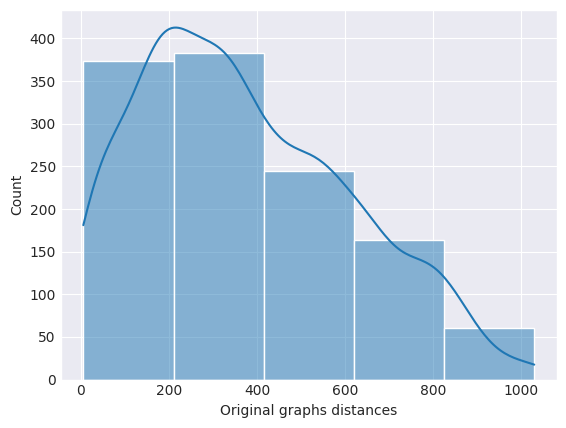

In [261]:
#sns.histplot(data=dist, bins=5, kde=True).set(title='Original graphs')

ax = sns.histplot(data=Gdist, bins=5, kde=True)
ax.set(xlabel='Original graphs distances', ylabel='Count')
plt.show()

[Text(0.5, 1.0, 'Graph2Vec')]

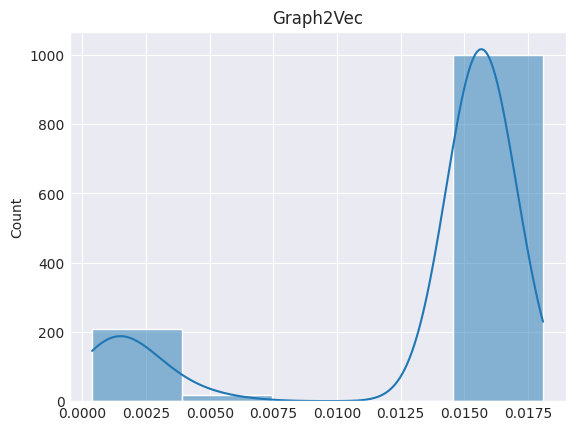

In [262]:
sns.histplot(data=Y, bins=5, kde=True).set(title='Graph2Vec')
#Y = distancias Graph2Vec

[Text(0.5, 1.0, 'GL2Vec')]

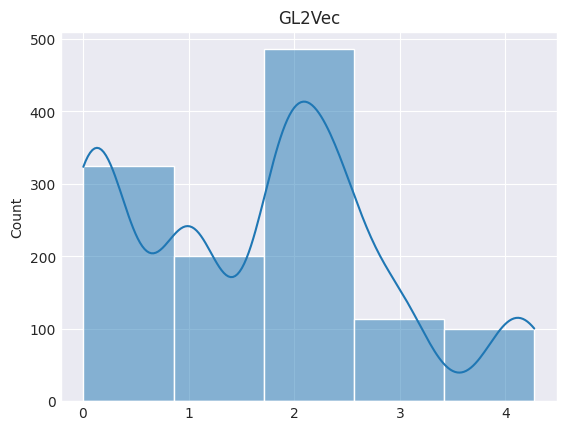

In [263]:
sns.histplot(data=Y1, bins=5, kde=True).set(title='GL2Vec')
#Y1 = distancias GL2Vec

[Text(0.5, 1.0, 'Wavelet Characteristic')]

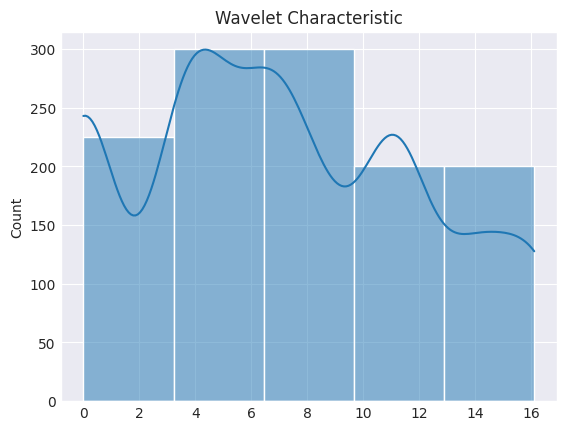

In [264]:
sns.histplot(data=Y2, bins=5, kde=True).set(title='Wavelet Characteristic')
#Y2 = distancias Wavelets

## histogramas normalizados

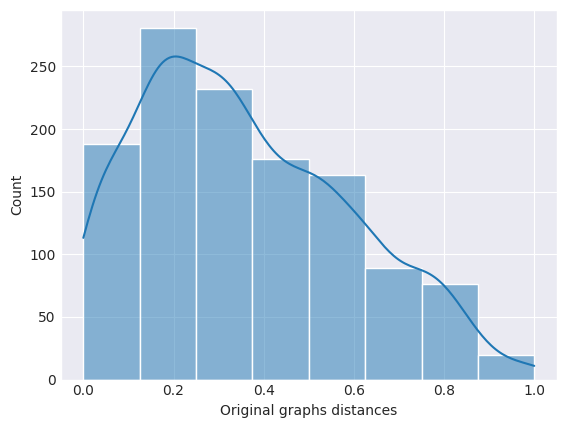

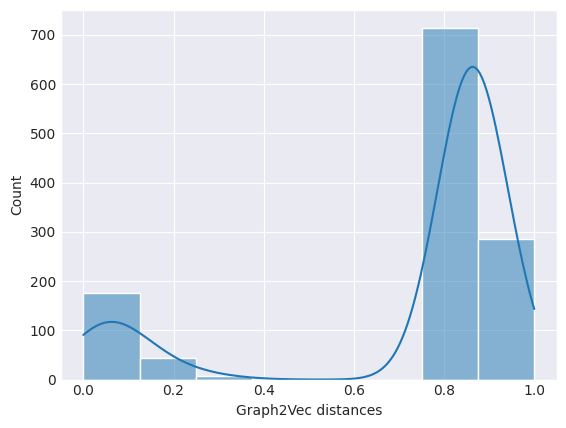

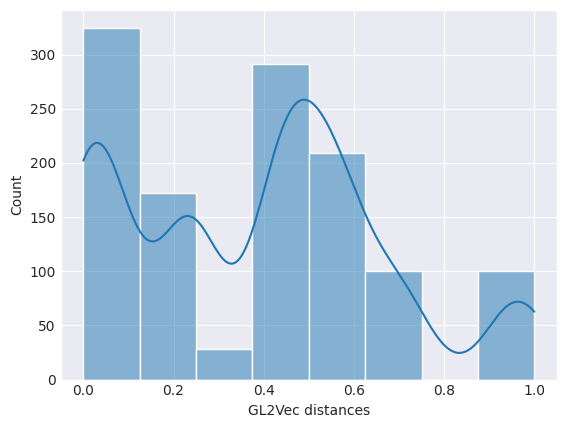

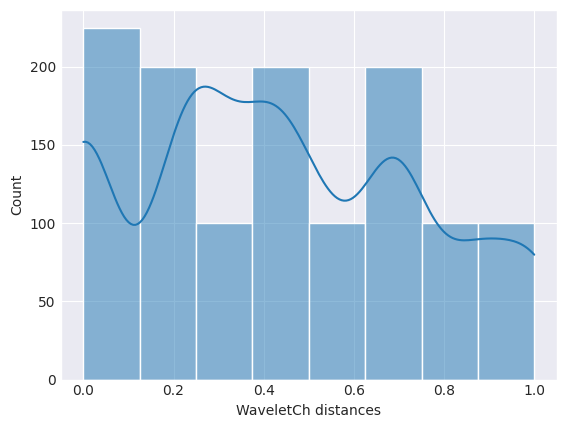

In [265]:
hist_graphDistN = sns.histplot(data=scaled_data['GraphDist'], bins=8, kde=True)
hist_graphDistN.set(xlabel='Original graphs distances', ylabel='Count')
plt.show()

hist_Graph2VecN = sns.histplot(data=scaled_data['Graph2Vec'], bins=8, kde=True)
hist_Graph2VecN.set(xlabel='Graph2Vec distances', ylabel='Count')
plt.show()

hist_GL2VecN = sns.histplot(data=scaled_data['GL2Vec'], bins=8, kde=True)
hist_GL2VecN.set(xlabel='GL2Vec distances', ylabel='Count')
plt.show()

hist_WaveletChN = sns.histplot(data=scaled_data['WaveletCh'], bins=8, kde=True)
hist_WaveletChN.set(xlabel='WaveletCh distances', ylabel='Count')
plt.show()